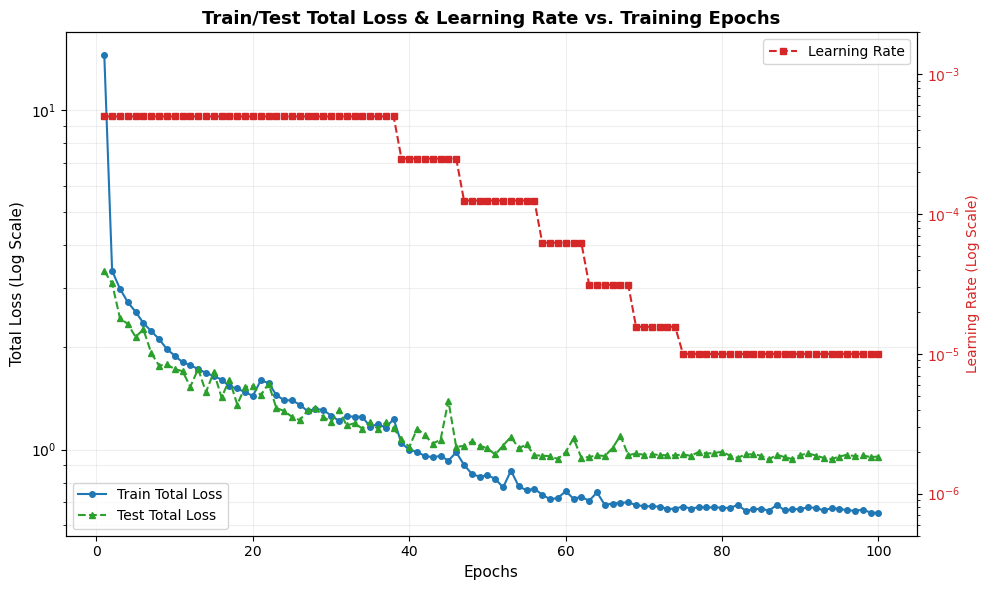

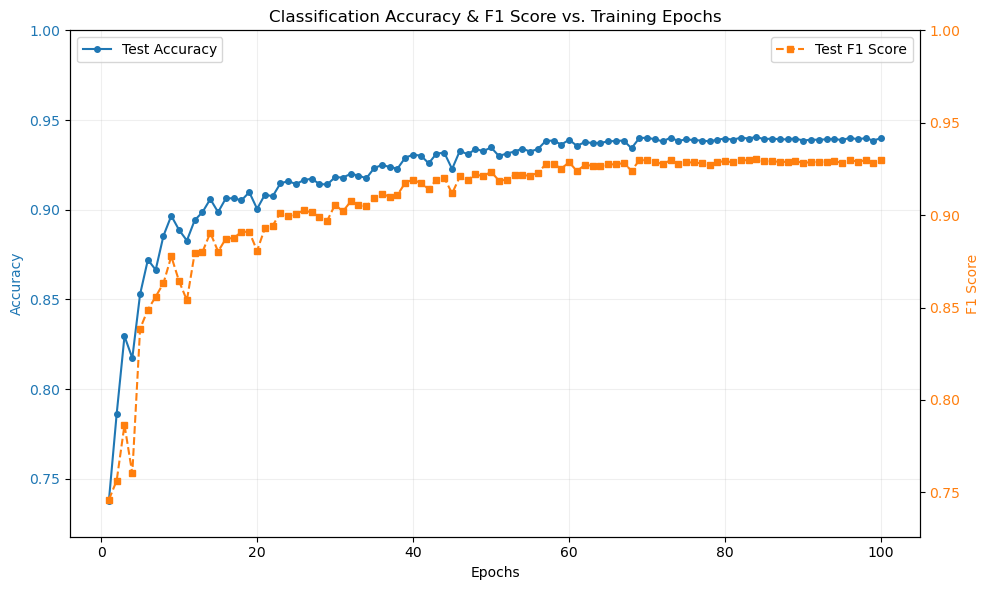

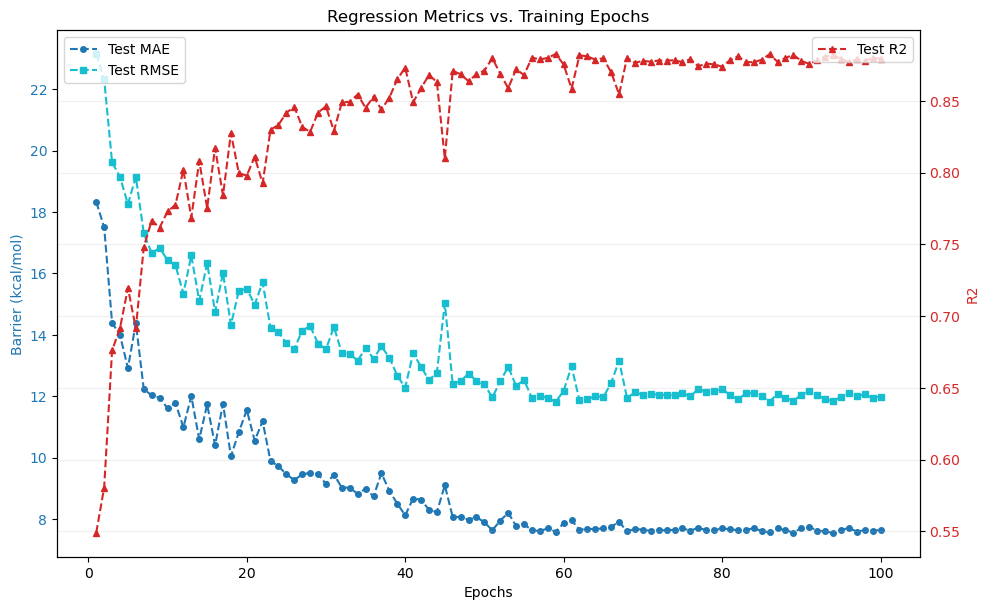

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt


# 日志文件路径（保持你的原始路径）
# log_file = './t1x_dim64_h8_n3_do0.2_w20_lrf0.8_lrp10_lr1e-3_ep200_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1762264378.0235028/log.json'
# log_file = './DFT/t1x_dim128_h8_n3_do0.2_w20_lrf0.7_lrp5_lr1e-3_ep100_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1763536170.2708519/log.json'
log_file = '/inspire/hdd/project/chemicalreaction/misixuan-CZXS24220243/sii/MyWork/atomic_foundation/Uni-Reaction-Release/DFT/t1x_dim128_h8_n3_do0.2_w20_lrf0.5_lrp5_lr5e-4_ep100_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1763538855.794973/log.json'

# 读取日志文件
with open(log_file, 'r') as f:
    log_data = json.load(f)

# 提取训练轮数
epochs = range(1, len(log_data['train_total_loss']) + 1)

# --------------------------
# 1. 总损失（左侧）+ 学习率（右侧）双y轴图
# --------------------------
# 训练集总损失
train_total_loss = log_data['train_total_loss']
# 学习率
train_lr = log_data['current_lr']
# 测试集总损失（从每轮test_metric中提取validation_loss→total_loss）
test_total_loss = []
for test_metric in log_data['test_metric']:
    # 从测试集指标中获取总损失（与eval_joint返回的validation_loss对应）
    test_total = test_metric['validation_loss']['total_loss']
    test_total_loss.append(test_total)

# 创建双y轴图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：训练集+测试集总损失（共用对数刻度）
color_train = 'tab:blue'
color_test = 'tab:green'
ax1.set_xlabel('Epochs', fontsize=11)
ax1.set_ylabel('Total Loss (Log Scale)', fontsize=11)
# 训练集loss：蓝色实线+圆形标记
ax1.plot(epochs, train_total_loss, label='Train Total Loss', 
         marker='o', markersize=4, color=color_train, linewidth=1.5)
# 测试集loss：绿色虚线+三角形标记（区分训练集）
ax1.plot(epochs, test_total_loss, label='Test Total Loss', 
         marker='^', markersize=4, color=color_test, linewidth=1.5, linestyle='--')
ax1.set_yscale('log')  # 保留对数刻度，便于观察损失变化
ax1.tick_params(axis='y', labelcolor='black')  # 损失轴标签用黑色（两个曲线共用）
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, which="both", ls="-", alpha=0.2)

# 右侧y轴：学习率（对数刻度，适配指数衰减）
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Learning Rate (Log Scale)', color=color2)
ax2.plot(epochs, train_lr, label='Learning Rate', marker='s', markersize=4, color=color2, linestyle='--')
ax2.set_yscale('log')  # 学习率用对数刻度更清晰
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(5e-7, 2e-3)
ax2.legend(loc='upper right')

plt.title('Train/Test Total Loss & Learning Rate vs. Training Epochs', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# --------------------------
# 2. 分类准确率（左侧）+ F1分数（右侧）双y轴图
# --------------------------
# 提取测试集的ACC和F1（从classification指标中获取）
test_acc = [item['classification']['ACC'] for item in log_data['test_metric']]
test_f1 = [item['classification']['F1'] for item in log_data['test_metric']]  # 新增F1提取

# 创建双y轴图
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：分类准确率
color1 = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy', color=color1)
ax1.plot(epochs, test_acc, label='Test Accuracy', marker='o', markersize=4, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(max(0, min(test_acc) - 0.02), 1.0)  # 调整y轴范围，避免刻度太紧凑
ax1.legend(loc='upper left')
ax1.grid(True, ls="-", alpha=0.2)

# 右侧y轴：F1分数
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('F1 Score', color=color2)
ax2.plot(epochs, test_f1, label='Test F1 Score', marker='s', markersize=4, color=color2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(max(0, min(test_f1) - 0.02), 1.0)  # F1与ACC同范围（0-1）
ax2.legend(loc='upper right')

plt.title('Classification Accuracy & F1 Score vs. Training Epochs')
fig.tight_layout()
plt.show()

# --------------------------
# 3. 回归指标图（保持原始代码不变）
# --------------------------
# 提取测试集回归指标
test_mae = [item['regression']['MAE'] for item in log_data['test_metric']]
test_mse = [item['regression']['MSE'] for item in log_data['test_metric']]
test_rmse = [np.sqrt(mse) for mse in test_mse]  # 计算RMSE
test_r2 = [item['regression']['R2'] for item in log_data['test_metric']]

fig, ax1 = plt.subplots(figsize=(10, 6))

# 左侧y轴：MAE和RMSE
color = 'tab:blue'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Barrier (kcal/mol)', color=color)
ax1.plot(epochs, test_mae, label='Test MAE', marker='o', markersize=4, linestyle='--', color='tab:blue')
ax1.plot(epochs, test_rmse, label='Test RMSE', marker='s', markersize=4, linestyle='--', color='tab:cyan')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')

# 创建右侧y轴：R2
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('R2', color=color)  
ax2.plot(epochs, test_r2, label='Test R2', marker='^', markersize=4, linestyle='--', color='tab:red')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')

fig.tight_layout()  
plt.title('Regression Metrics vs. Training Epochs')
plt.grid(True, ls="-", alpha=0.2)
plt.show()

📊 分类阈值分析结果
最优阈值（Youden指数最大化）：0.5018
对应性能：TPR=0.9288, FPR=0.0606


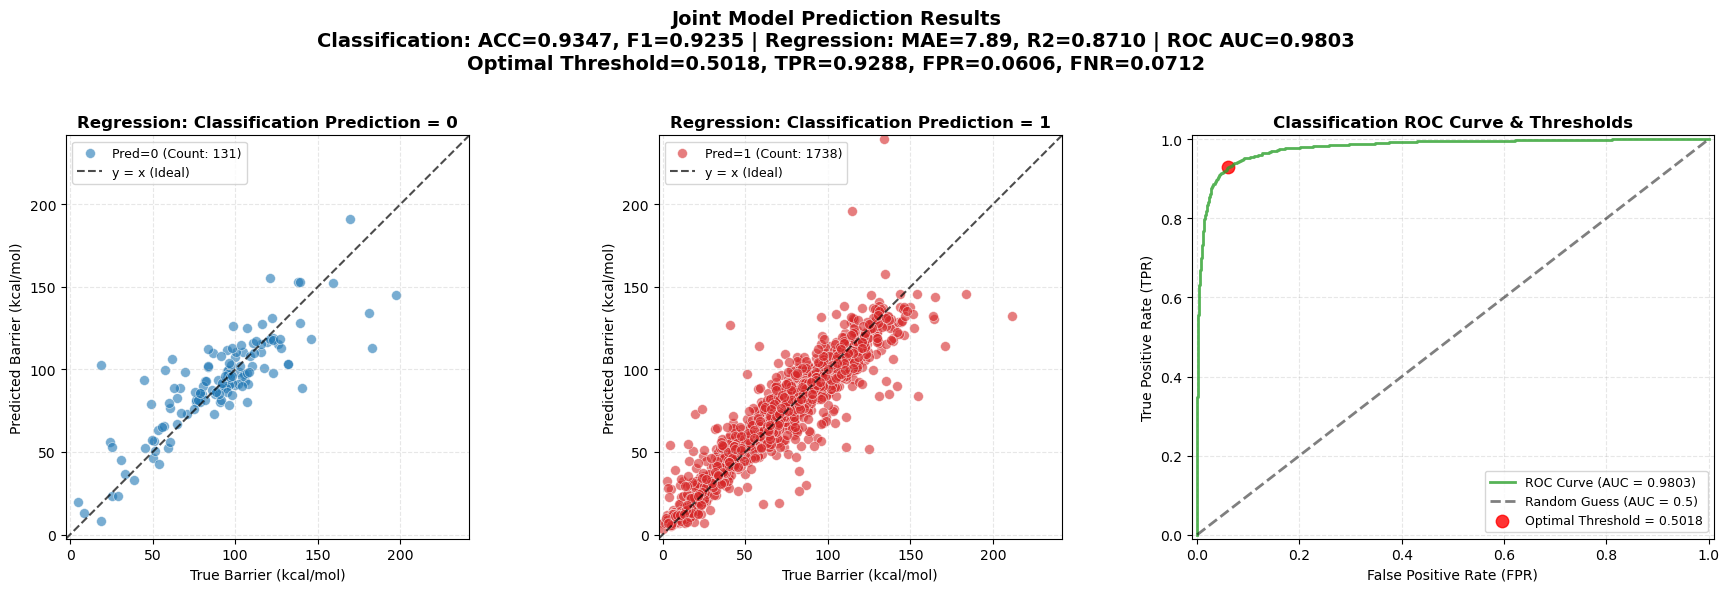

In [12]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math
from sklearn.metrics import roc_curve, auc, confusion_matrix

# --------------------------
# 配置参数（根据实际路径修改）
# --------------------------
json_file = '/inspire/hdd/project/chemicalreaction/misixuan-CZXS24220243/sii/MyWork/atomic_foundation/Uni-Reaction-Release/DFT/t1x_dim128_h8_n3_do0.2_w20_lrf0.5_lrp5_lr5e-4_ep100_bs128_ns0.2_lh4_fixed_lbd5e-3_focalloss2.0/1763538855.794973/t1x_test.json'

# --------------------------
# 1. 读取并解析JSON数据
# --------------------------
with open(json_file, 'r') as f:
    data = json.load(f)

# 提取核心数据
reg_true_raw = data['regression']['true_values']
reg_pred_raw = data['regression']['pred_values']
cls_true_raw = data['classification']['true_labels']
cls_pred_raw = data['classification']['pred_labels']
cls_metrics = data['classification']['metrics']
reg_metrics = data['regression']['metrics']

# 读取正类预测得分（计算阈值必需）
try:
    cls_scores_raw = data['classification']['cls_scores']  # 正类的logits/概率
except KeyError:
    raise ValueError("计算阈值需要正类预测得分！请修改eval_joint函数，添加'cls_scores'（正类logits或概率）")

# --------------------------
# 2. 数据预处理（过滤无效值）
# --------------------------
# 回归数据预处理
reg_true = []
reg_pred = []
cls_pred = []
for t_reg, p_reg, t_cls, p_cls in zip(reg_true_raw, reg_pred_raw, cls_true_raw, cls_pred_raw):
    if isinstance(t_reg, (int, float)) and isinstance(p_reg, (int, float)):
        if not (math.isnan(t_reg) or math.isnan(p_reg)):
            reg_true.append(t_reg)
            reg_pred.append(p_reg)
            cls_pred.append(p_cls)

# 分类&阈值计算数据预处理（仅保留有效标签和得分）
valid_data = []
for t_cls, p_cls, score_cls in zip(cls_true_raw, cls_pred_raw, cls_scores_raw):
    if (isinstance(t_cls, (int, float)) and isinstance(score_cls, (int, float)) and
        t_cls in [0, 1] and p_cls in [0, 1]):
        valid_data.append((t_cls, p_cls, score_cls))

cls_true_auc = [x[0] for x in valid_data]
cls_scores_auc = [x[2] for x in valid_data]
cls_pred_valid = [x[1] for x in valid_data]
cls_scores_valid = [x[2] for x in valid_data]

# --------------------------
# 3. 关键计算（含阈值分析）
# --------------------------
# 回归数据范围
if reg_true and reg_pred:
    min_val = min(min(reg_true), min(reg_pred))
    max_val = max(max(reg_true), max(reg_pred))
    val_range = max_val - min_val
    min_plot = min_val - 0.01 * val_range
    max_plot = max_val + 0.01 * val_range
else:
    min_plot, max_plot = 0, 1

# 分类指标
acc = cls_metrics['ACC']
f1 = cls_metrics['F1']
mae = reg_metrics['MAE']
r2 = reg_metrics['R2']

# --------------------------
# 核心：计算分类阈值（重点）
# --------------------------
# 3.1 计算最优阈值（基于Youden指数：TPR - FPR 最大化）
fpr, tpr, thresholds = roc_curve(cls_true_auc, cls_scores_auc, pos_label=1)
roc_auc = auc(fpr, tpr)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]  # 最优阈值
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

# # 3.2 推断模型实际使用的阈值（从预测标签反推）
# # 逻辑：预测为1的最小得分 ≈ 实际阈值（允许微小误差）
# score_1 = [s for p, s in zip(cls_pred_valid, cls_scores_valid) if p == 1]  # 预测1的得分
# score_0 = [s for p, s in zip(cls_pred_valid, cls_scores_valid) if p == 0]  # 预测0的得分
# actual_threshold = None
# if score_1 and score_0:
#     min_score_1 = min(score_1)
#     max_score_0 = max(score_0)
#     if min_score_1 >= max_score_0:
#         actual_threshold = (min_score_1 + max_score_0) / 2  # 取中间值作为实际阈值
#     else:
#         # 存在得分交叉（可能是噪声），用最优阈值替代参考
#         actual_threshold = optimal_threshold
#         print(f"⚠️ 预测得分存在交叉，实际阈值参考最优阈值：{actual_threshold:.4f}")
# elif score_1:
#     actual_threshold = min(score_1) - 0.01  # 预测全为1，阈值略低于最小得分
# elif score_0:
#     actual_threshold = max(score_0) + 0.01  # 预测全为0，阈值略高于最大得分

# 输出阈值结果
print("="*50)
print("📊 分类阈值分析结果")
print(f"最优阈值（Youden指数最大化）：{optimal_threshold:.4f}")
print(f"对应性能：TPR={optimal_tpr:.4f}, FPR={optimal_fpr:.4f}")
# print(f"模型实际使用的阈值（反推）：{actual_threshold:.4f}")
# print(f"默认阈值（常见参考）：0.5")
print("="*50)

# --------------------------
# 4. 绘图（一行三列，ROC图标注阈值）
# --------------------------
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# 子图1：分类预测=0的回归散点图
reg_true_0 = [t for t, p in zip(reg_true, cls_pred) if p == 0]
reg_pred_0 = [pr for pr, p in zip(reg_pred, cls_pred) if p == 0]
ax1.scatter(reg_true_0, reg_pred_0, color='tab:blue', alpha=0.6,
            label=f'Pred=0 (Count: {len(reg_true_0)})', s=50, edgecolors='white', linewidth=0.5)
ax1.plot([min_plot, max_plot], [min_plot, max_plot], 'k--', alpha=0.7, label='y = x (Ideal)')
ax1.set_xlabel('True Barrier (kcal/mol)', fontsize=10)
ax1.set_ylabel('Predicted Barrier (kcal/mol)', fontsize=10)
ax1.set_title('Regression: Classification Prediction = 0', fontsize=12, fontweight='bold')
ax1.set_xlim(min_plot, max_plot)
ax1.set_ylim(min_plot, max_plot)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# 子图2：分类预测=1的回归散点图
reg_true_1 = [t for t, p in zip(reg_true, cls_pred) if p == 1]
reg_pred_1 = [pr for pr, p in zip(reg_pred, cls_pred) if p == 1]
ax2.scatter(reg_true_1, reg_pred_1, color='tab:red', alpha=0.6,
            label=f'Pred=1 (Count: {len(reg_true_1)})', s=50, edgecolors='white', linewidth=0.5)
ax2.plot([min_plot, max_plot], [min_plot, max_plot], 'k--', alpha=0.7, label='y = x (Ideal)')
ax2.set_xlabel('True Barrier (kcal/mol)', fontsize=10)
ax2.set_ylabel('Predicted Barrier (kcal/mol)', fontsize=10)
ax2.set_title('Regression: Classification Prediction = 1', fontsize=12, fontweight='bold')
ax2.set_xlim(min_plot, max_plot)
ax2.set_ylim(min_plot, max_plot)
ax2.set_aspect('equal', adjustable='box')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, linestyle='--')

# 子图3：ROC图（标注最优阈值）
ax3.plot(fpr, tpr, color='tab:green', lw=2, alpha=0.8, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax3.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random Guess (AUC = 0.5)')
# 标注最优阈值点（红色圆点）
ax3.scatter(optimal_fpr, optimal_tpr, color='red', s=80, alpha=0.8, 
            label=f'Optimal Threshold = {optimal_threshold:.4f}')
# 标注实际阈值对应的点（蓝色三角）
# if actual_threshold is not None:
#     # 计算实际阈值对应的FPR和TPR
#     actual_pred = (np.array(cls_scores_auc) >= actual_threshold).astype(int)
#     cm = confusion_matrix(cls_true_auc, actual_pred)
#     if cm.shape == (2, 2):
#         tn, fp, fn, tp = cm.ravel()
#         actual_tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
#         actual_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
#         ax3.scatter(actual_fpr, actual_tpr, color='blue', s=80, marker='^', alpha=0.8,
#                     label=f'Actual Threshold = {actual_threshold:.4f}')

ax3.set_xlabel('False Positive Rate (FPR)', fontsize=10)
ax3.set_ylabel('True Positive Rate (TPR)', fontsize=10)
ax3.set_title('Classification ROC Curve & Thresholds', fontsize=12, fontweight='bold')
ax3.set_xlim([-0.01, 1.01])
ax3.set_ylim([-0.01, 1.01])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, linestyle='--')

# 总标题（包含阈值信息）
fig.suptitle(
    f'Joint Model Prediction Results\n'
    f'Classification: ACC={acc:.4f}, F1={f1:.4f} | '
    f'Regression: MAE={mae:.2f}, R2={r2:.4f} | '
    f'ROC AUC={roc_auc:.4f}\n'
    f'Optimal Threshold={optimal_threshold:.4f}, TPR={optimal_tpr:.4f}, FPR={optimal_fpr:.4f}, FNR={1-optimal_tpr:.4f}',
    # f'Optimal Threshold={optimal_threshold:.4f}, Actual Threshold={actual_threshold:.4f}',
    fontsize=14, fontweight='bold', y=0.98
)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # 预留更多空间显示总标题
plt.show()

# 保存高清图片
# fig.savefig('./prediction_results_with_thresholds.png', dpi=300, bbox_inches='tight')
# print("图表已保存，包含阈值标注！")